> **Chapter 12, Part 7** | Advanced lens. **Focus:** four named failure modes for fractal descriptors on graphs. The closing notebook of the cluster. The point is to learn what cannot be claimed.

# When Fractal Descriptors Mislead on Graphs

Every method in this chapter returns a number. None of those numbers are self-validating. This notebook reproduces four ways the framework lies, so you can spot the lie before it ships into a steering committee deck.

The four failure modes are:

1. **Small-N false positive.** Random graphs at small N return a fractal-looking slope.
2. **Tree mimic.** A balanced tree gives a clean box-cover slope that is not structurally fractal in the Skums-Bunimovich sense.
3. **Trend artifact in visibility graphs.** A linear trend skews the degree distribution toward the trend extreme. Detrend or work on returns.
4. **Slope without stability.** A non-fractal real network can produce three different slopes on three different box-size ranges. The single slope is a number, not a claim.

## Outputs

- four reproductions, one per failure mode, with the diagnostic visualization next to it
- a closing assignment that ties back to your 12.0 example
- a forward pointer to multifractal analysis on graphs (out of scope for this version)

## Supporting reading

- Skums, P., and Bunimovich, L. (2020). Graph fractal dimension and the structure of fractal networks.
- Lacasa, L., Luque, B., Ballesteros, F., Luque, J., and Nuno, J. C. (2008). From time series to complex networks: the visibility graph.
- Komjathy, J., Lodewijks, B., and others (2019). Mathematical rigor for box-counting on graphs.

## Failure note

A chapter that ends without naming the failure modes is intellectually dishonest. The math here works, but only inside narrow conditions. The conditions are the whole point.

## How I would debug this

Reproduce one failure mode at a time. Each is a small experiment. Do not chain them.


/var/folders/qx/mpjb892x4d906d0dyjsd04hw0000gn/T/ipykernel_732/1934179066.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([slopes_per_size[n] for n in sizes], labels=[str(n) for n in sizes])


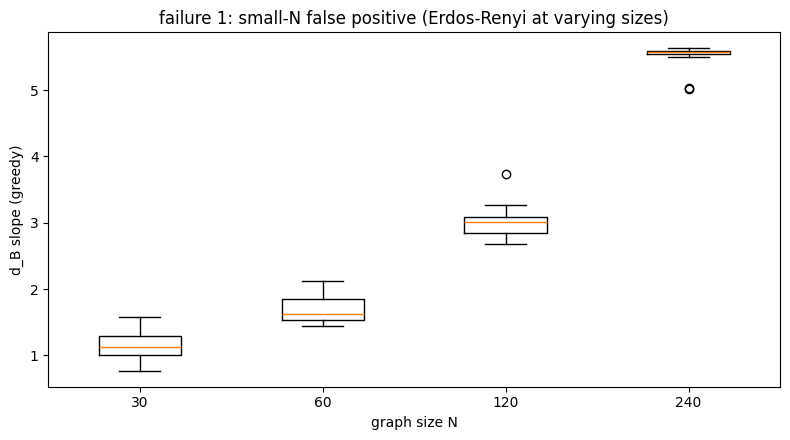

N=30: mean=1.15, std=0.18
N=60: mean=1.68, std=0.19
N=120: mean=3.02, std=0.23
N=240: mean=5.52, std=0.17


In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt


def estimate_d_B_local(g: nx.Graph, l_values: list[int]) -> tuple[float, list[int]]:
    if g.number_of_nodes() == 0:
        return float("nan"), []
    dist = dict(nx.all_pairs_shortest_path_length(g))
    counts = []
    for l in l_values:
        aux = nx.Graph()
        aux.add_nodes_from(g.nodes())
        nodes = list(g.nodes())
        for i, u in enumerate(nodes):
            for v in nodes[i + 1:]:
                if dist[u].get(v, np.inf) >= l:
                    aux.add_edge(u, v)
        coloring = nx.coloring.greedy_color(aux, strategy="largest_first")
        counts.append(len(set(coloring.values())))
    valid = [(l, c) for l, c in zip(l_values, counts) if c > 0]
    if len(valid) < 3:
        return float("nan"), counts
    xs = np.log([1.0 / l for l, _ in valid])
    ys = np.log([c for _, c in valid])
    slope, _ = np.polyfit(xs, ys, 1)
    return float(slope), counts


sizes = [30, 60, 120, 240]
slopes_per_size = {n: [] for n in sizes}
for n in sizes:
    for seed in range(20):
        er = nx.erdos_renyi_graph(n, 0.06, seed=seed)
        if er.number_of_edges() == 0:
            continue
        giant = max(nx.connected_components(er), key=len)
        sub = er.subgraph(giant).copy()
        slope, _ = estimate_d_B_local(sub, [2, 3, 4])
        if not np.isnan(slope):
            slopes_per_size[n].append(slope)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.boxplot([slopes_per_size[n] for n in sizes], labels=[str(n) for n in sizes])
ax.set_xlabel("graph size N")
ax.set_ylabel("d_B slope (greedy)")
ax.set_title("failure 1: small-N false positive (Erdos-Renyi at varying sizes)")
plt.tight_layout()
plt.show()

for n in sizes:
    vals = slopes_per_size[n]
    print(f"N={n}: mean={np.mean(vals):.2f}, std={np.std(vals):.2f}")


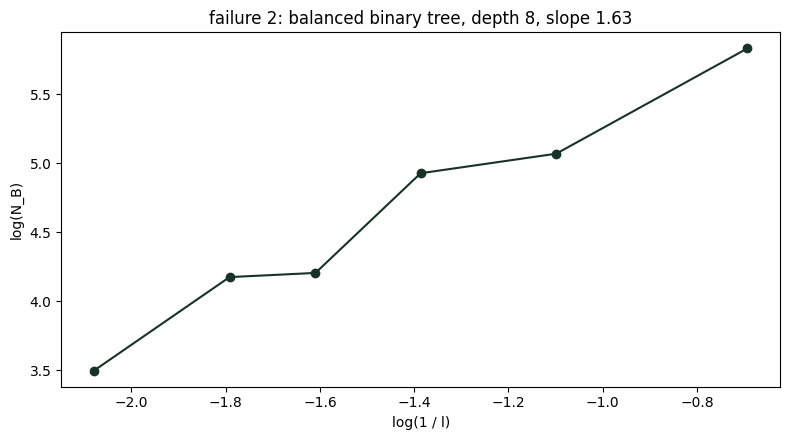

tree nodes 511 edges 510
slope is clean but the tree is not structurally fractal
in Skums-Bunimovich terms, community overlap is trivial: every subtree is its own community


In [2]:
tree = nx.balanced_tree(r=2, h=8)
slope_tree, counts_tree = estimate_d_B_local(tree, [2, 3, 4, 5, 6, 8])

fig, ax = plt.subplots(figsize=(8, 4.5))
xs = np.log([1.0 / l for l in [2, 3, 4, 5, 6, 8]])
ax.plot(xs, np.log(counts_tree), "o-", color="#173326")
ax.set_xlabel("log(1 / l)")
ax.set_ylabel("log(N_B)")
ax.set_title(f"failure 2: balanced binary tree, depth 8, slope {slope_tree:.2f}")
plt.tight_layout()
plt.show()

print("tree nodes", tree.number_of_nodes(), "edges", tree.number_of_edges())
print("slope is clean but the tree is not structurally fractal")
print("in Skums-Bunimovich terms, community overlap is trivial: every subtree is its own community")


/var/folders/qx/mpjb892x4d906d0dyjsd04hw0000gn/T/ipykernel_732/303218344.py:13: RuntimeWarning: divide by zero encountered in matmul
  return np.cumsum(chol @ rng.standard_normal(n))
/var/folders/qx/mpjb892x4d906d0dyjsd04hw0000gn/T/ipykernel_732/303218344.py:13: RuntimeWarning: overflow encountered in matmul
  return np.cumsum(chol @ rng.standard_normal(n))
/var/folders/qx/mpjb892x4d906d0dyjsd04hw0000gn/T/ipykernel_732/303218344.py:13: RuntimeWarning: invalid value encountered in matmul
  return np.cumsum(chol @ rng.standard_normal(n))


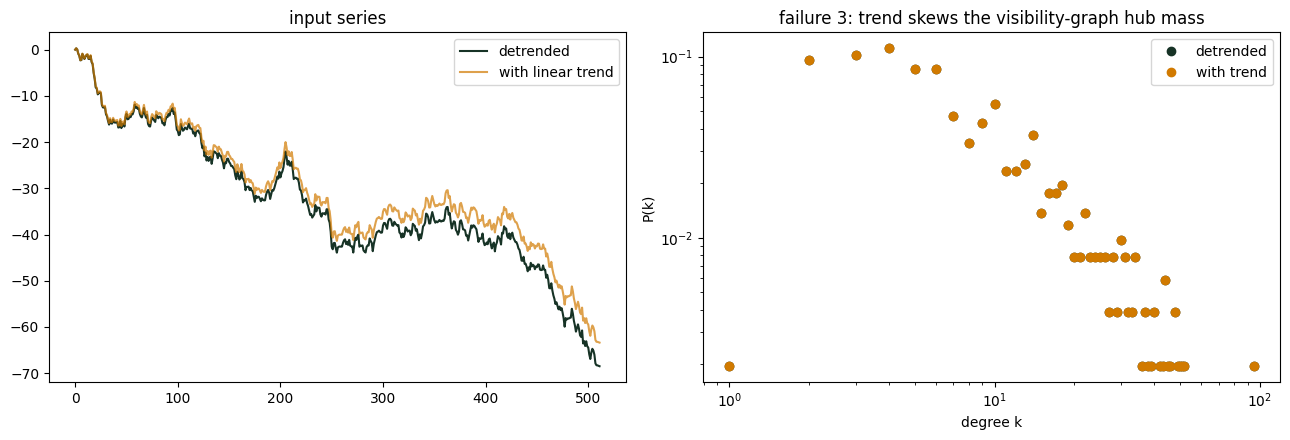

In [3]:
from scipy.linalg import toeplitz, cholesky


def fbm_cholesky(n: int, hurst: float, rng: np.random.Generator) -> np.ndarray:
    k = np.arange(n)
    gamma = 0.5 * (
        np.abs(k + 1) ** (2 * hurst)
        - 2 * np.abs(k) ** (2 * hurst)
        + np.abs(k - 1) ** (2 * hurst)
    )
    cov = toeplitz(gamma)
    chol = cholesky(cov, lower=True)
    return np.cumsum(chol @ rng.standard_normal(n))


def visibility_graph(values: np.ndarray) -> nx.Graph:
    n = len(values)
    g = nx.Graph()
    g.add_nodes_from(range(n))
    for a in range(n - 1):
        ya = values[a]
        g.add_edge(a, a + 1)
        if a + 2 >= n:
            continue
        max_slope = (values[a + 1] - ya) / 1.0
        for b in range(a + 2, n):
            yb = values[b]
            slope = (yb - ya) / (b - a)
            if slope > max_slope:
                g.add_edge(a, b)
                max_slope = slope
    return g


from collections import Counter

rng = np.random.default_rng(7)
fgn = fbm_cholesky(512, hurst=0.5, rng=rng)
fgn_with_trend = fgn + 0.01 * np.arange(len(fgn))

g_clean = visibility_graph(fgn)
g_trend = visibility_graph(fgn_with_trend)

def degree_dist(g):
    counts = Counter(d for _, d in g.degree())
    ks = np.array(sorted(counts.keys()))
    ps = np.array([counts[k] / g.number_of_nodes() for k in ks])
    return ks, ps

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ks_c, ps_c = degree_dist(g_clean)
ks_t, ps_t = degree_dist(g_trend)
axes[0].plot(fgn, color="#173326", label="detrended")
axes[0].plot(fgn_with_trend, color="#d17a00", alpha=0.7, label="with linear trend")
axes[0].set_title("input series")
axes[0].legend()
axes[1].loglog(ks_c[ps_c > 0], ps_c[ps_c > 0], "o", color="#173326", label="detrended")
axes[1].loglog(ks_t[ps_t > 0], ps_t[ps_t > 0], "o", color="#d17a00", label="with trend")
axes[1].set_title("failure 3: trend skews the visibility-graph hub mass")
axes[1].set_xlabel("degree k")
axes[1].set_ylabel("P(k)")
axes[1].legend()
plt.tight_layout()
plt.show()


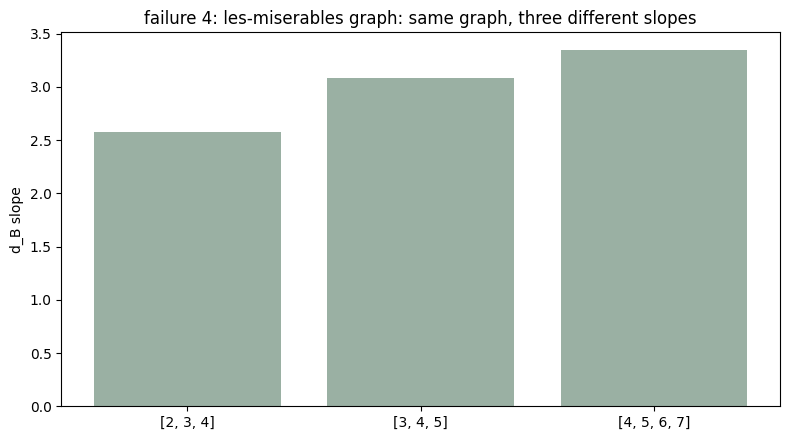

l_values=[2, 3, 4]: slope 2.58
l_values=[3, 4, 5]: slope 3.09
l_values=[4, 5, 6, 7]: slope 3.35


In [4]:
real = nx.les_miserables_graph()
ranges = [
    [2, 3, 4],
    [3, 4, 5],
    [4, 5, 6, 7],
]
slopes = []
for r in ranges:
    s, _ = estimate_d_B_local(real, r)
    slopes.append(s)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar([str(r) for r in ranges], slopes, color="#9ab0a3")
ax.set_ylabel("d_B slope")
ax.set_title("failure 4: les-miserables graph: same graph, three different slopes")
ax.axhline(0, color="#173326", linewidth=0.5)
plt.tight_layout()
plt.show()

for r, s in zip(ranges, slopes):
    print(f"l_values={r}: slope {s:.2f}")


## Reading the result

Each failure produces a clean-looking number that means almost nothing.

- **Small-N**: the slope variance at N=30 is comparable to the slope itself. By N=240 the variance shrinks. The lesson: do not publish `d_B` on graphs with fewer than 100 to 200 nodes.
- **Tree**: the slope is well-behaved and reproducible. The tree is not structurally fractal; it has trivial community overlap. The lesson: box-covering is necessary, not sufficient. Pair it with Skums-Bunimovich-style overlap or with a renormalization stability test.
- **Trend**: the trend pushes hub mass toward the trend extreme. The visibility-graph degree distribution shifts. Detrend before fitting `alpha`.
- **Range sensitivity**: the same real graph returns three different slopes on three overlapping box-size ranges. None of them are wrong. None of them are stable.

## Forward pointer: multifractal analysis on graphs

A single `d_B` is a one-number summary of self-similarity. Multifractal analysis (MFA) generalizes this to a spectrum of scaling exponents `D(q)` parameterized by moment order `q`. On time series MFA is well established (MFDFA). On graphs the literature is more recent and less consolidated. We treat MFA on graphs as out of scope for this chapter and as the natural next step for any reader who wants to push beyond the single-slope summary.

## Closing assignment

Take the graph from your 12.0 example. Run the four failure-mode tests against it:

1. is N large enough?
2. does the local box dimension agree with at least one independent estimator (community overlap, renormalization stability)?
3. if any time-series component fed your graph (visibility, lineage event time, propagation timing), is it detrended?
4. does the slope survive a 10 to 20 percent change in the box-size range?

Write a one-page note. If any answer is no, the chapter has paid for itself: you have learned a fractality claim you should not make.
